# 04 — M2/L3: FRC Crossing with Standardized Effect Sizes by Demographic

**Pipeline stage:** the inferential follow-up to M2 Level&nbsp;3. A Wilcoxon p-value tells you the
*sign* of the above→below-FRC shift is reliable, but not whether the shift is large relative to its
own spread. This notebook adds **Cohen's d**, robust d, bootstrap CIs, sign-consistency, and a
**demographic stratification** (Young/Elder × Male/Female).

**Scripts reproduced**
| Script | Role |
|--------|------|
| `scripts/analyze_l3_stratified.py` | segment collection, effect sizes, forest & stratified histograms |
| `pneumophonic_analysis/effect_size.py` | `compute_paired_effect_size` (Cohen's d, robust d, Wilcoxon r, bootstrap CIs) |
| `scripts/make_m2_summary_plots.py` | Cohen's-d comparison bar chart, orthogonality scatter |

> **Plot types:** forest plot (median + bootstrap CI), 2×2 stratified histograms,
> grouped Cohen's-d bar chart with qualitative reference lines, orthogonality scatter with group medians.

## 0. Setup

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))

import analyze_l3_stratified as l3
from analyze_l3_stratified import STRATA_ORDER, FRC_TASKS, FEATURES, UNITS
from make_m2_summary_plots import DEMO_COLORS
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
META_PATH  = REPO / "data_root" / "healthy_subjects" / "subjects_metadata.csv"
print("FRC tasks:", FRC_TASKS, "| features:", FEATURES)

FRC tasks: ['a_2', 'a_3', 'a_7'] | features: ['f0', 'energy', 'pct_rc', 'flow_cw']


## 1. Collect FRC-split segments
`l3.collect_paired_segments` walks the sustained-task HDF5 files, splits each at the FRC crossing,
computes above/below feature means, and joins subject sex/age.

In [2]:

metadata = l3.load_metadata(META_PATH)
seg_df = l3.collect_paired_segments(PAIRED_DIR, metadata, tasks=FRC_TASKS)
seg_df = l3.assign_demographic_group(seg_df.dropna(subset=['sex', 'age']), age_threshold=55)
print(f"{len(seg_df)} segments | {seg_df['subject_id'].nunique()} subjects")
print("Demographics:", seg_df['demographic'].value_counts().to_dict())
seg_df[['subject_id','task','demographic','f0_above','f0_below','pct_rc_above','pct_rc_below']].head()

2026-06-11 16:25:46,588 - analyze_l3_stratified - INFO - Found 550 paired HDF5 files in C:\Users\Matéo\OneDrive\Documents\GitHub\pneumophonic_pipeline\data_target\healthy_subjects\paired
2026-06-11 16:25:51,370 - analyze_l3_stratified - INFO - Segments: kept=86  skipped_task=439  skipped_split=9  skipped_voiced=16
2026-06-11 16:25:51,370 - analyze_l3_stratified - INFO -   FRC crossing method: {'genuine': 67, 'midpoint': 19}
2026-06-11 16:25:51,370 - analyze_l3_stratified - WARNING - No metadata for 1 subject(s): ['CaBl']. They will be excluded from stratified analysis.


85 segments | 37 subjects
Demographics: {'YM': 23, 'EM': 22, 'YF': 21, 'EF': 19}


,subject_id,task,demographic,f0_above,f0_below,pct_rc_above,pct_rc_below
0,AlMo,a_2,YM,106.681667,108.494118,0.711294,0.732634
1,AlMo,a_7,YM,119.658927,184.030345,0.700858,0.701388
2,AlVi,a_2,YF,169.038315,169.656747,0.726295,0.730832
3,AnCa,a_2,EF,172.773459,173.277747,0.610865,0.623942
4,AnCa,a_3,EF,190.102452,190.211275,0.617157,0.625404


## 2. Stratified effect-size table
`l3.stratified_effect_sizes` runs `compute_paired_effect_size` for each feature across the nine
strata. Below, the overall (`All`) row for every feature.

In [3]:

summaries = [l3.stratified_effect_sizes(seg_df, f, age_threshold=55) for f in FEATURES]
summary = pd.concat(summaries, ignore_index=True)
cols = ['feature','stratum','n_segments','median_shift','cohen_d','cohen_d_label',
        'sign_consistency','wilcoxon_p']
display(summary[summary['stratum']=='All'][cols].round(4).reset_index(drop=True))

,feature,stratum,n_segments,median_shift,cohen_d,cohen_d_label,sign_consistency,wilcoxon_p
0,f0,All,85,2.3851,0.5951,medium,0.7176,0.0000
1,energy,All,85,-0.0068,-0.0032,negligible,0.6471,0.0667
2,pct_rc,All,85,0.0066,1.1691,large,0.9176,0.0000
3,flow_cw,All,85,0.0115,-0.0029,negligible,0.5765,0.1602


## 3. Forest plot — F0 shift across strata
Median below−above shift with bootstrap 95% CI; blue markers are Wilcoxon-significant (p<0.05),
Cohen's d and sign-consistency annotated on the right. This is the headline L3 figure.

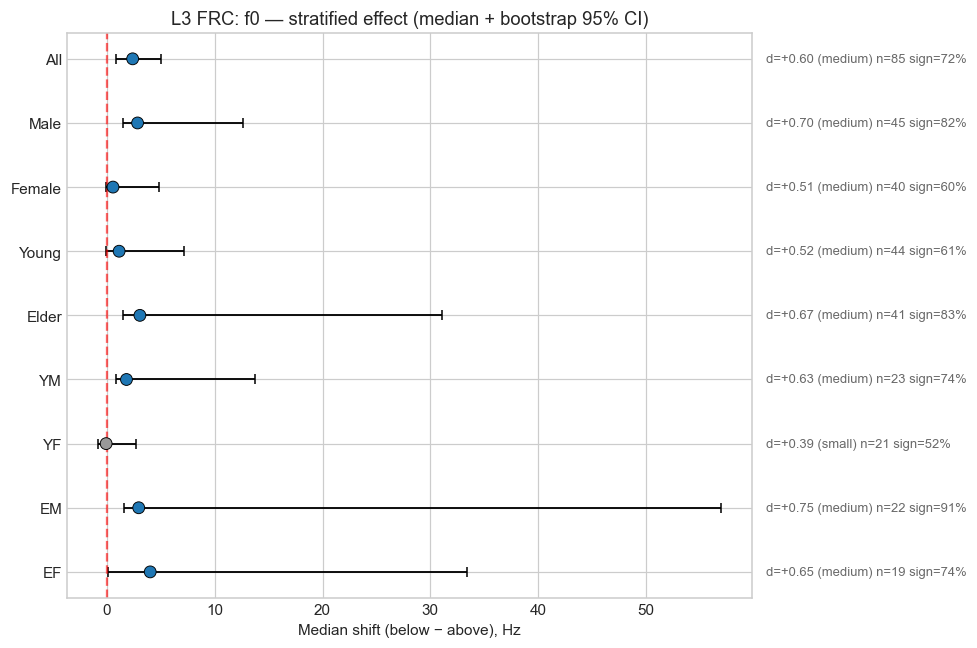

In [4]:

def forest(summary, feature):
    sub = summary[summary['feature']==feature].copy()
    sub['__o'] = sub['stratum'].apply(lambda s: STRATA_ORDER.index(s) if s in STRATA_ORDER else 99)
    sub = sub.sort_values('__o').reset_index(drop=True)
    y = np.arange(len(sub))
    med = sub['median_shift'].values
    elo = med - sub['median_ci_lo'].values; ehi = sub['median_ci_hi'].values - med
    fig, ax = plt.subplots(figsize=(9, 0.5*len(sub)+1.5))
    ax.errorbar(med, y, xerr=[elo, ehi], fmt='none', ecolor='black', elinewidth=1.2, capsize=3, zorder=2)
    colors = ['#1f77b4' if p < 0.05 else '#999999' for p in sub['wilcoxon_p']]
    ax.scatter(med, y, c=colors, s=60, edgecolor='black', linewidth=0.6, zorder=3)
    ax.axvline(0, color='red', ls='--', alpha=0.6)
    ax.set_yticks(y); ax.set_yticklabels(sub['stratum']); ax.invert_yaxis()
    ax.set_xlabel(f'Median shift (below − above), {UNITS.get(feature,"")}')
    ax.set_title(f"L3 FRC: {feature} — stratified effect (median + bootstrap 95% CI)")
    for i, r in enumerate(sub.itertuples()):
        ax.text(1.02, y[i], f"d={r.cohen_d:+.2f} ({r.cohen_d_label}) n={r.n_segments} sign={r.sign_consistency:.0%}",
                transform=ax.get_yaxis_transform(), va='center', fontsize=8.5, color='dimgray')
    plt.tight_layout(); plt.show()

forest(summary, 'f0')

> **Observe:** the f0-shift forest — every stratum's CI sits right of zero (f0 rises below FRC), but the effect is **medium** (d≈0.5–0.75), with wide CIs in the small cells (YF). Direction consistent, magnitude modest.

### 3b. Forest plot — %RC shift
The rib-cage contribution shift; contrast its demographic pattern with F0 above.

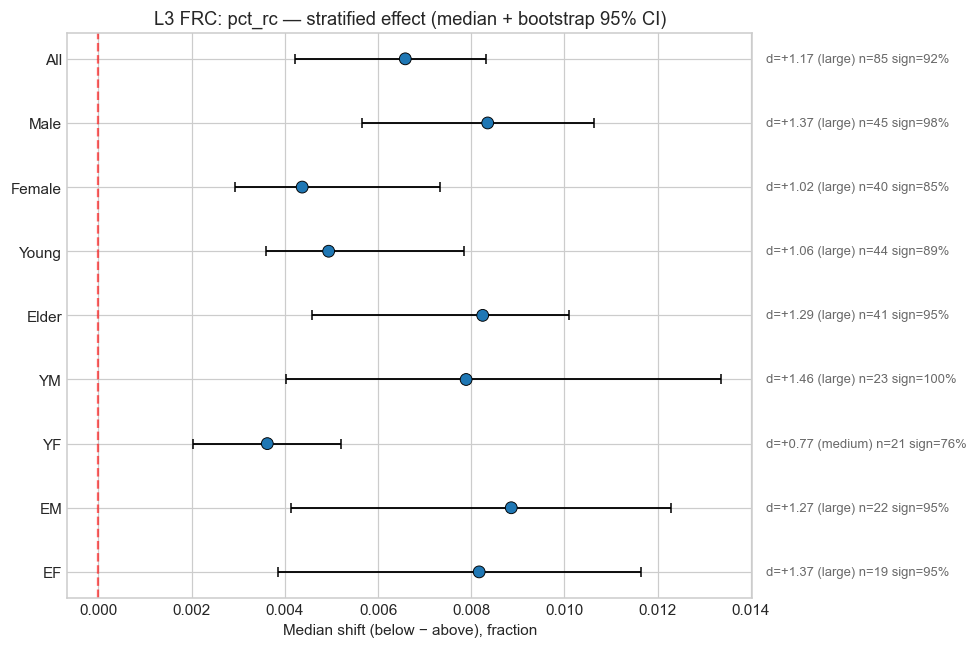

In [5]:
forest(summary, 'pct_rc')

> **Observe:** the %RC forest — CIs clearly right of zero with **large** effects (d≈1.0–1.5), strongest in young males and the elderly. %RC is the robust FRC-crossing marker (the rib cage re-weights as the lung empties).

## 4. Per-segment shift histograms by subgroup (F0)
2×2 small multiples — one panel per Young/Elder × Male/Female cell — of the raw per-segment
below−above shift, with median and Cohen's d annotated.

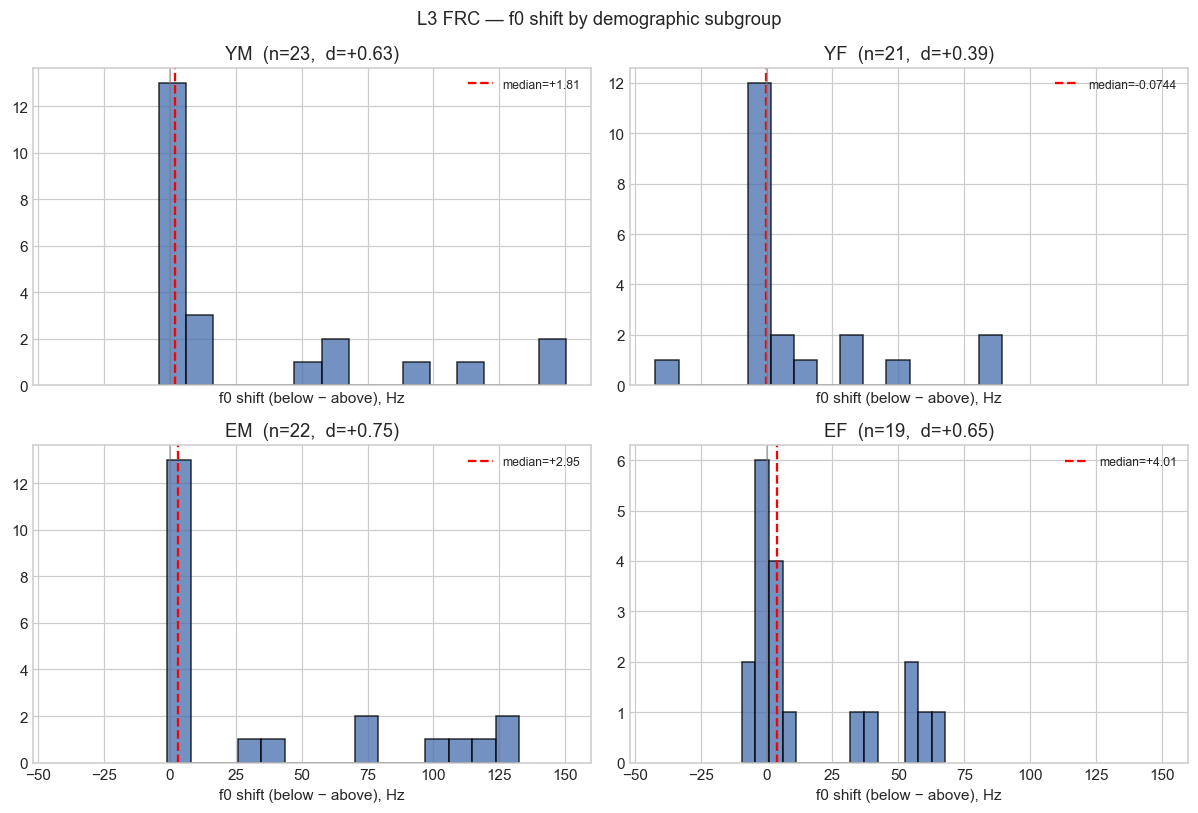

In [6]:

def strat_hist(seg_df, feature):
    df = l3.assign_demographic_group(seg_df.dropna(subset=['sex','age']), 55).copy()
    df['shift'] = df[f'{feature}_below'] - df[f'{feature}_above']
    df = df.dropna(subset=['shift'])
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    for ax, g in zip(axes.flat, ['YM','YF','EM','EF']):
        s = df[df['demographic']==g]
        if len(s) >= 3:
            ax.hist(s['shift'], bins=15, color='#4c72b0', alpha=0.78, edgecolor='black')
            med = s['shift'].median(); sd = s['shift'].std(ddof=1)
            d = s['shift'].mean()/sd if sd>0 else np.nan
            ax.axvline(med, color='red', ls='--', lw=1.5, label=f'median={med:+.3g}')
            ax.axvline(0, color='gray', lw=1, alpha=0.6)
            ax.set_title(f'{g}  (n={len(s)},  d={d:+.2f})'); ax.legend(fontsize=8)
        else:
            ax.set_title(f'{g} (n={len(s)} — insufficient)')
        ax.set_xlabel(f'{feature} shift (below − above), {UNITS.get(feature,"")}')
    fig.suptitle(f'L3 FRC — {feature} shift by demographic subgroup', fontsize=12)
    plt.tight_layout(); plt.show()

strat_hist(seg_df, 'f0')

> **Observe:** per-stratum shift histograms — f0/%RC shifts are predominantly positive (below>above FRC) with tight same-sign distributions in the strong cells; YF is broader/noisier (small n, weakest coupling).

## 5. Cohen's d comparison across strata
Grouped bars (F0 vs %RC) for the nine strata, with Cohen's qualitative bins (small/medium/large)
as dotted reference lines. The headline of `make_m2_summary_plots.py`.

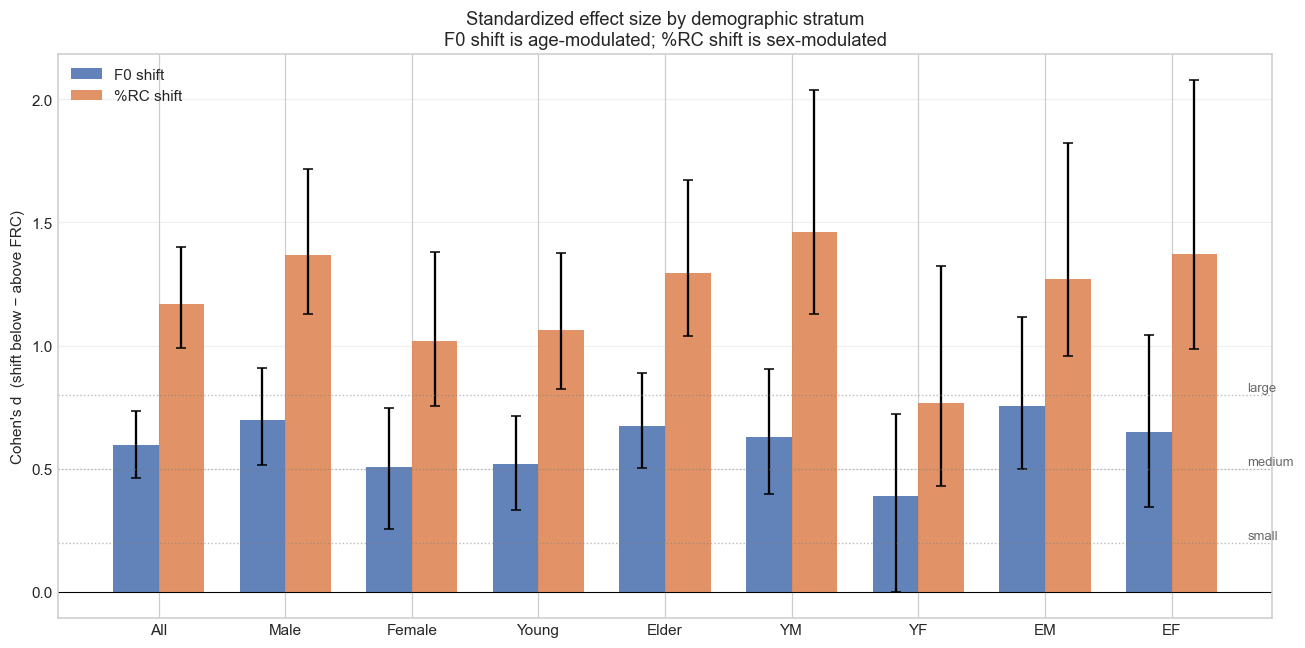

In [7]:

def aligned(feature):
    return summary[summary['feature']==feature].set_index('stratum').reindex(STRATA_ORDER)
f0, rc = aligned('f0'), aligned('pct_rc')
x = np.arange(len(STRATA_ORDER)); w = 0.36
def yerr(s): return np.vstack([s['cohen_d']-s['cohen_d_ci_lo'], s['cohen_d_ci_hi']-s['cohen_d']])

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x-w/2, f0['cohen_d'], w, yerr=yerr(f0), label='F0 shift', color='#4c72b0', alpha=0.88, capsize=3.5)
ax.bar(x+w/2, rc['cohen_d'], w, yerr=yerr(rc), label='%RC shift', color='#dd8452', alpha=0.88, capsize=3.5)
for d, lab in [(0.2,'small'),(0.5,'medium'),(0.8,'large')]:
    ax.axhline(d, color='gray', ls=':', alpha=0.55, lw=0.9)
    ax.text(len(x)-0.4, d+0.015, lab, fontsize=8.5, color='dimgray')
ax.axhline(0, color='black', lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(STRATA_ORDER)
ax.set_ylabel("Cohen's d  (shift below − above FRC)")
ax.set_title("Standardized effect size by demographic stratum\nF0 shift is age-modulated; %RC shift is sex-modulated")
ax.legend(loc='upper left', frameon=False); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

> **Observe:** the headline bars — **%RC (d>1, large) towers over f0 (d≈0.6, medium)** in every stratum. The FRC crossing is marked far more by *which compartment* drives the breath than by a pitch change; both are weakest in young females.

## 6. Orthogonality scatter — F0 shift vs %RC shift
Each point is one sustained-phonation segment, coloured by demographic; the **X** markers are group
medians. The two axes carry largely independent demographic information (F0↔age, %RC↔sex).

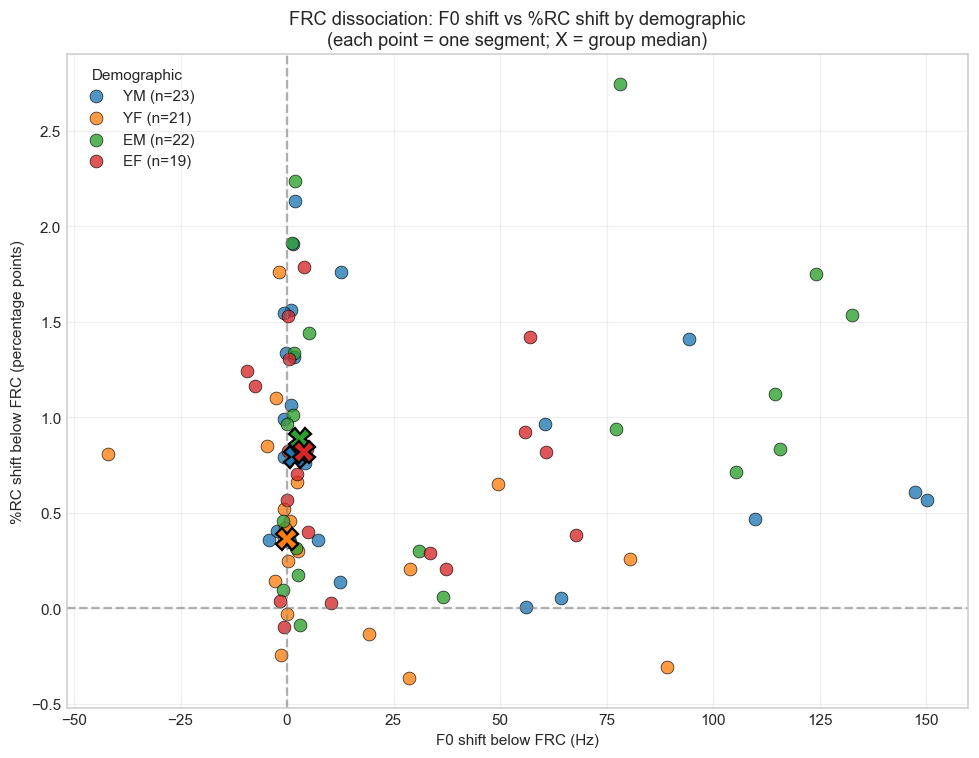

In [8]:

df = seg_df.dropna(subset=['demographic']).copy()
df['f0_shift'] = df['f0_below'] - df['f0_above']
df['pct_rc_shift_pp'] = (df['pct_rc_below'] - df['pct_rc_above']) * 100
df = df.dropna(subset=['f0_shift', 'pct_rc_shift_pp'])

fig, ax = plt.subplots(figsize=(9, 7))
for demo in ['YM','YF','EM','EF']:
    s = df[df['demographic']==demo]
    if len(s)==0: continue
    ax.scatter(s['f0_shift'], s['pct_rc_shift_pp'], c=DEMO_COLORS[demo],
               label=f'{demo} (n={len(s)})', alpha=0.78, s=70, edgecolor='black', linewidth=0.5)
    if len(s) >= 3:
        ax.plot(s['f0_shift'].median(), s['pct_rc_shift_pp'].median(), marker='X', markersize=14,
                color=DEMO_COLORS[demo], markeredgecolor='black', markeredgewidth=1.5, zorder=5)
ax.axhline(0, color='gray', ls='--', alpha=0.6); ax.axvline(0, color='gray', ls='--', alpha=0.6)
ax.set_xlabel('F0 shift below FRC (Hz)'); ax.set_ylabel('%RC shift below FRC (percentage points)')
ax.set_title("FRC dissociation: F0 shift vs %RC shift by demographic\n(each point = one segment; X = group median)")
ax.legend(title='Demographic', loc='upper left'); ax.grid(alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

> **Observe:** F0-shift and %RC-shift are **largely orthogonal** — no strong diagonal, and the demographic medians (X) separate along different axes (F0↔age, %RC↔sex). They carry *independent* respiratory information, so both are worth keeping.

## Recap
Standardized effect sizes turn the L3 "is the shift real?" question into "how big, and for whom?".
To regenerate the full Excel summary + PDF forest/histogram set and the summary plots:

```bash
python scripts/analyze_l3_stratified.py --paired-dir data_target/healthy_subjects/paired     --metadata data_root/healthy_subjects/subjects_metadata.csv --output-dir results/M2_stratified
python scripts/make_m2_summary_plots.py --results-dir results/M2_stratified
```

Notebooks **05** and **06** move to M3: trying to *predict* the respiratory state from audio.

## Stratified cross-domain correlations — which feature & task couple?

Beyond the FRC effect sizes, we ask **which acoustic feature and which task give a consistent audio↔physiology coupling**, per demographic stratum. For every recording we take the within-segment Pearson *r* between each acoustic feature (f0, energy, spectral centroid) and each OEP feature (Δvcw, flow, %RC, %AB) over voiced frames, then aggregate by task × stratum (`scripts/analyze_stratified_crossdomain.py` → `M2_crossdomain/`).

**Headline.** In *steady* phonation the coupling is **modest** — energy↔volume ≈ **+0.24** (strongest steady coupling, a touch higher in elderly males), spectral-centroid↔volume ≈ +0.15, and acoustic↔**flow** ≈ **0**. The one **strong, universal** coupling is **f0 ↔ chest-wall volume in the vocal glide `a_7` (r ≈ −0.88, 100% sign-consistent in every stratum)** — but that is *active* pitch modulation. Take-away: voice tracks lung **volume (position)**, not **flow (rate)**; strong couplings appear only when the task deliberately modulates the feature.

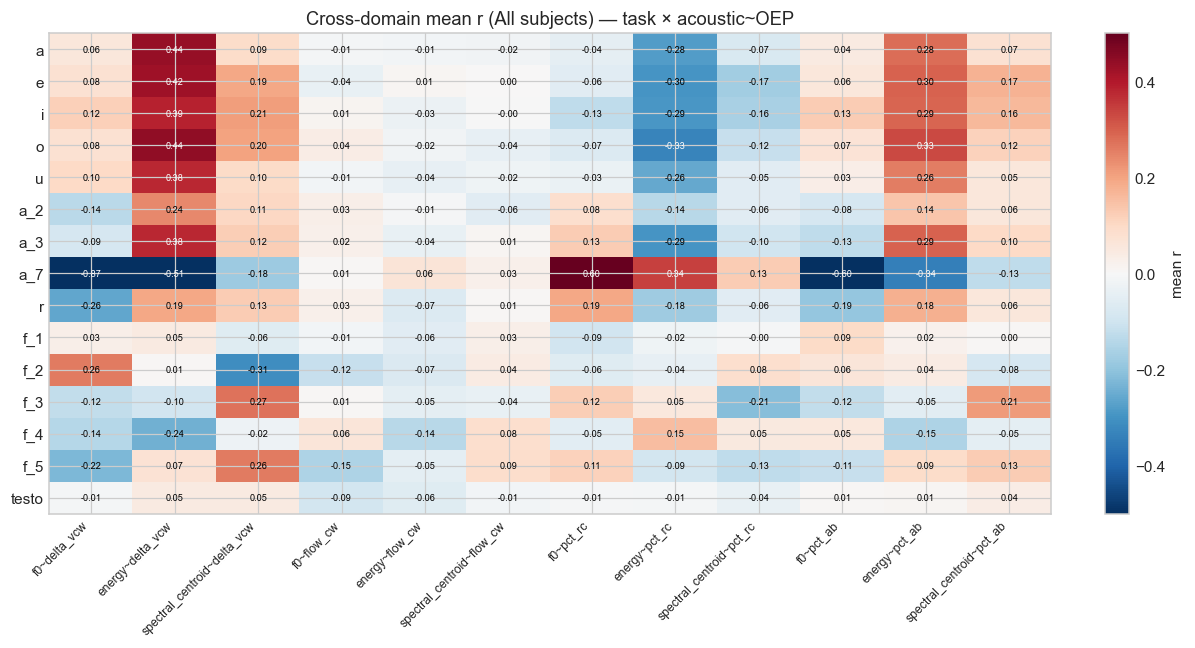

Top consistent cross-domain couplings (sustained tasks):


,stratum,task,pair,mean_r,sign_consistency,n
1079,YM,a_7,f0~delta_vcw,-0.91,1.0,9
267,Male,a_7,f0~delta_vcw,-0.91,1.0,18
1479,EM,a_7,f0~delta_vcw,-0.90,1.0,9
675,Young,a_7,f0~delta_vcw,-0.89,1.0,19
63,All,a_7,f0~delta_vcw,-0.87,1.0,36
1275,YF,a_7,f0~delta_vcw,-0.86,1.0,10
879,Elder,a_7,f0~delta_vcw,-0.85,1.0,17
471,Female,a_7,f0~delta_vcw,-0.83,1.0,18
1713,EF,a_7,f0~pct_ab,-0.82,1.0,8
1728,EF,a_7,f0~pct_rc,0.82,1.0,8


In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
cd = REPO/"data_target/healthy_subjects/M2_crossdomain/crossdomain_by_task_stratum.csv"
if cd.exists():
    S = pd.read_csv(cd)
    po=[f"{x}~{o}" for o in ['delta_vcw','flow_cw','pct_rc','pct_ab'] for x in ['f0','energy','spectral_centroid']]
    tasks=['a','e','i','o','u','a_2','a_3','a_7','r','f_1','f_2','f_3','f_4','f_5','testo']
    piv=(S[S['stratum']=='All'].pivot_table(index='task',columns='pair',values='mean_r')
         .reindex(index=[t for t in tasks if t in set(S['task'])], columns=po))
    fig,ax=plt.subplots(figsize=(11,6)); im=ax.imshow(piv.values,cmap='RdBu_r',vmin=-.5,vmax=.5,aspect='auto')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns,rotation=45,ha='right',fontsize=8)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v=piv.values[i,j]
            if np.isfinite(v): ax.text(j,i,f"{v:.2f}",ha='center',va='center',fontsize=6,color='black' if abs(v)<.32 else 'white')
    ax.set_title('Cross-domain mean r (All subjects) — task × acoustic~OEP'); fig.colorbar(im,ax=ax,fraction=.025,label='mean r')
    plt.tight_layout(); plt.show()
    top=S[(S['task'].isin(['a','e','i','o','u','a_2','a_3','a_7','r']))&(S['n']>=6)].copy()
    top['score']=top['mean_r'].abs()*top['sign_consistency']
    print('Top consistent cross-domain couplings (sustained tasks):')
    display(top.sort_values('score',ascending=False).head(10)[['stratum','task','pair','mean_r','sign_consistency','n']].round(2))
else:
    print('Run scripts/analyze_stratified_crossdomain.py to generate M2_crossdomain/.')

### One example on all three domains — the genuine FRC crossing (glide `a_7`)

With the baseline-referenced FRC, **67/86 sustained segments now cross the *true* resting volume** (only 19 fall back to the midpoint proxy). The honest effect sizes at the genuine crossing: **f0-shift is medium** (d=0.60 overall, stronger in elderly males d=0.75; f0 rises below FRC), while **`%RC` is the large-effect marker** (d=1.17, up to 1.46 in young males, 100% sign-consistent). The figure below shows one glide: chest-wall volume crossing FRC (col 1, the dashed line = resting FRC level), the loudness envelope (col 2), and F0 sweeping with the harmonics (col 3).

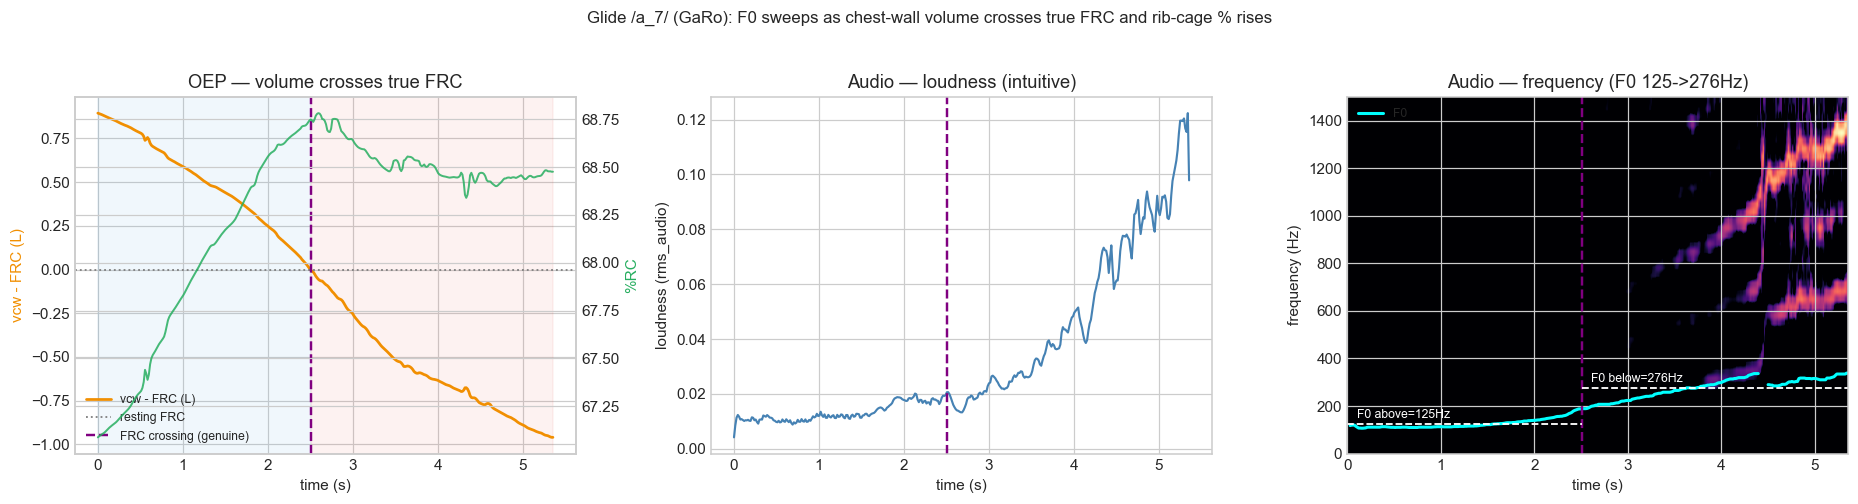

In [10]:
import numpy as np, matplotlib.pyplot as plt, h5py
from pneumophonic_analysis.paired_features import PairedFeatureExtractor
from analyze_l3_stratified import find_frc_crossing_index, find_genuine_frc_crossing
H5 = REPO/"data_target/healthy_subjects/paired/GaRo_a_7.h5"
df,meta=PairedFeatureExtractor.load_hdf5(H5)
t=df['time'].values; pr=df['pct_rc'].values*100
f0=df['f0'].where(df['voiced']==1.0).values
amp=(df['rms_audio'] if 'rms_audio' in df.columns else df['energy']).values
dvf=df['delta_vcw_frc'].values if 'delta_vcw_frc' in df.columns else df['delta_vcw'].values
ci=find_genuine_frc_crossing(dvf) if 'delta_vcw_frc' in df.columns else None
if ci is None: ci=find_frc_crossing_index(df['delta_vcw'].values)
tc=t[ci]; fa=np.nanmean(f0[:ci]); fb=np.nanmean(f0[ci:])
with h5py.File(H5,'r') as f: S=f['stft'][:]; sr=int(f.attrs['sr_audio'])
freqs=np.linspace(0,sr/2,S.shape[0]); km=np.searchsorted(freqs,1500); Sdb=20*np.log10(S[:km]+1e-6)
fig,ax=plt.subplots(1,3,figsize=(17,4.4))
a=ax[0]; a.plot(t,dvf,color='#F18F01',lw=1.8,label='vcw - FRC (L)'); a.axhline(0,color='gray',ls=':',lw=1.2,label='resting FRC')
a.axvline(tc,color='purple',lw=1.6,ls='--',label='FRC crossing (genuine)'); a.axvspan(t[0],tc,color='#3498DB',alpha=.07); a.axvspan(tc,t[-1],color='#E74C3C',alpha=.07)
a.set_xlabel('time (s)'); a.set_ylabel('vcw - FRC (L)',color='#F18F01'); b=a.twinx(); b.plot(t,pr,color='#27AE60',lw=1.3,alpha=.85); b.set_ylabel('%RC',color='#27AE60')
a.set_title('OEP — volume crosses true FRC'); a.legend(loc='lower left',fontsize=8)
a=ax[1]; a.plot(t,amp,color='steelblue',lw=1.4); a.axvline(tc,color='purple',lw=1.6,ls='--'); a.set_xlabel('time (s)'); a.set_ylabel('loudness (rms_audio)'); a.set_title('Audio — loudness (intuitive)')
a=ax[2]; a.imshow(Sdb,origin='lower',aspect='auto',extent=[t[0],t[-1],0,1500],cmap='magma',vmin=Sdb.max()-70,vmax=Sdb.max())
a.plot(t,f0,color='cyan',lw=2,label='F0'); a.axvline(tc,color='purple',lw=1.6,ls='--')
a.hlines(fa,t[0],tc,color='w',ls='--',lw=1.2); a.hlines(fb,tc,t[-1],color='w',ls='--',lw=1.2)
a.text(t[0]+.1,fa+25,f'F0 above={fa:.0f}Hz',color='w',fontsize=8); a.text(tc+.1,fb+25,f'F0 below={fb:.0f}Hz',color='w',fontsize=8)
a.set_ylim(0,1500); a.set_xlabel('time (s)'); a.set_ylabel('frequency (Hz)'); a.set_title(f'Audio — frequency (F0 {fa:.0f}->{fb:.0f}Hz)'); a.legend(loc='upper left',fontsize=8)
fig.suptitle('Glide /a_7/ (GaRo): F0 sweeps as chest-wall volume crosses true FRC and rib-cage % rises',y=1.03,fontsize=11)
plt.tight_layout(); plt.show()